# Invariant QPINN on a neutral-atom device (QoolQit)

- **Quantum model.**
  - Step 1 encodes $x$ and $t$ as Pauli-$Z$ rotations.
  - Step 2 is a trainable pulse with **4 parameters**.
- **Hard constraint.** $u_\theta(x,t)=u_0(x)+(1-\cos t)\,f(x,t)$, so the initial condition holds for every $\theta$.
- **Invariant QPINN.** $f(x,t)=\tfrac12\big[f_\theta(x,t)+f_\theta(-x,-t)\big]$: run the circuit at $(x,t)$ and at $(-x,-t)$, then average. This is group averaging over the sign flip (arXiv:2610.01874).
- **Plain QPINN.** $f=f_\theta$, with everything else the same.
- **PDE.** $u_t+u_x=-A\sin(x+t)$ with $u(x,0)=A\cos x$. The exact solution $u^\ast=A\cos x\cos t$ is even.
- **Training.**
  - Derivatives: two-term parameter-shift rule.
  - Optimizer: Levenberg–Marquardt via `scipy.optimize.least_squares(method="lm")`.
  - Runs: one run per model, from the same starting point.
- **Backend.** `BACKEND = "qoolqit"` uses the QoolQit emulator; `"numpy"` uses an exact 4×4 simulation of the same Hamiltonian.

## 0. Setup

- **Backend.** `BACKEND = "qoolqit"` runs every circuit on the QoolQit emulator; `"numpy"` uses an exact 4×4 simulation of the same Hamiltonian.
- **Register.** Two atoms at distance 1, so $\tilde J_{01}=1$ (see §1.1). Atom 0 carries $x$, atom 1 carries $t$.
- **Device.** `AnalogDeviceWithDMM`: one global laser plus one detuning map modulator (DMM). With energy unit 1, one time unit is 1 µs.
- **Model size.** $K=2$ trainable phase segments, i.e. $2K=4$ parameters.

In [1]:
import json
import os
import time
from functools import reduce

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import least_squares
from qoolqit import Register, Drive, QuantumProgram, AnalogDeviceWithDMM, ConstantWaveform
from qoolqit.drive import DetuningMapModulator
from qoolqit.execution import LocalEmulator, EmulationConfig, Occupation

BACKEND = "qoolqit"                        # "qoolqit": QoolQit emulator   |   "numpy": exact 4x4 simulation, same Hamiltonian
RESULTS_DIR = "results_invariant_qpinn"
os.makedirs(RESULTS_DIR, exist_ok=True)

COORDS = [(0.0, 0.0), (1.0, 0.0)]          # atom 0 carries x, atom 1 carries t
J = 1.0 / np.linalg.norm(np.subtract(COORDS[0], COORDS[1])) ** 6   # = 1
T_P, T_E, T_M, T_Z = 0.5, 0.5, 0.4, 0.2   # durations (µs): preparation, encoding, mixing, trainable phase segment
OMEGA_M = (np.pi / 2) / T_M               # each mixing segment is about a pi/2 rotation of every atom
K = 2                                     # trainable phase segments -> 2K = 4 parameters
TWO_PI = 2 * np.pi
SHIFT = np.pi / 2                         # parameter-shift step (all generators have a single gap of 1)
print("total duration =", T_P + T_E + (K + 1) * T_M + K * T_Z, "µs")

register = Register.from_coordinates(COORDS)
device = AnalogDeviceWithDMM()            # AnalogDevice + one detuning map modulator (DMM)
device.set_energy_unit(1.0)               # 1 energy unit = 1 rad/µs  ->  1 time unit = 1 µs
emulator = LocalEmulator(emulation_config=EmulationConfig(observables=[Occupation(evaluation_times=[1.0])]))

total duration = 2.6 µs


## 1. Quantum model

### 1.1 Hamiltonian and preparation segment

**QoolQit model.** QoolQit writes the Hamiltonian of a neutral-atom register in dimensionless units
$$\tilde{H}(t)=\sum_{i<j}\tilde{J}_{ij}\,\hat{n}_i\hat{n}_j+\sum_i\frac{\tilde{\Omega}(t)}{2}\Big(\cos\phi(t)\,\hat{\sigma}^x_i-\sin\phi(t)\,\hat{\sigma}^y_i\Big)-\sum_i\Big(\tilde{\delta}(t)+\epsilon_i\,\tilde{\Delta}(t)\Big)\hat{n}_i ,$$

where $\hat{n}_i=\tfrac12\big(1+\hat{\sigma}^z_i\big)$ is the Rydberg occupation of atom $i$, and $\tilde{J}_{ij}=\tilde{r}_{ij}^{-6}$ is normalized so that $\max\tilde{J}_{ij}=1$. Here $t$ is pulse time. To avoid a clash with the PDE variable $t$, we write pulse time as $\tau$ from now on.

**Our choices.**

- $N=2$ atoms at `COORDS` $=(0,0),(1,0)$, so $\tilde{J}_{01}=1$.
- $\phi=0$ (the `Drive` default), so the drive term is $\tfrac{\tilde\Omega}{2}\hat{\sigma}^x_i$ only.
- $\epsilon_0=1$, $\epsilon_1=0$ (`weights={0: 1.0, 1: 0.0}`): the local detuning acts on atom 0 only.
- $\tilde{\Omega},\tilde{\delta},\tilde{\Delta}$ are constant inside each segment of the schedule (§1.2).

With these choices,

$$\tilde{H}(\tau)=\hat{n}_0\hat{n}_1+\frac{\tilde{\Omega}(\tau)}{2}\big(\hat{\sigma}^x_0+\hat{\sigma}^x_1\big)-\big(\tilde{\delta}(\tau)+\tilde{\Delta}(\tau)\big)\,\hat{n}_0-\tilde{\delta}(\tau)\,\hat{n}_1,\qquad \tilde{\Delta}(\tau)\le 0 .$$

So atom 1 sees the detuning $\tilde\delta$, and atom 0 sees $\tilde\delta+\tilde\Delta$.

**Pauli form.** We follow QoolQit's convention: $X_i=\hat{\sigma}^x_i$ and $Z_i=\hat{\sigma}^z_i=2\hat{n}_i-1$, so $Z_i=+1$ on the Rydberg state and $-1$ on the ground state. Then

$$\tilde{H}(\tau)=\frac{\tilde{\Omega}(\tau)}{2}\big(X_0+X_1\big)+\Big(\frac14-\frac{\tilde{\delta}(\tau)+\tilde{\Delta}(\tau)}{2}\Big)Z_0+\Big(\frac14-\frac{\tilde{\delta}(\tau)}{2}\Big)Z_1+\frac14\,Z_0Z_1+c(\tau)\,\mathbb{1},$$

with $c(\tau)=\tfrac14-\tilde{\delta}(\tau)-\tfrac12\tilde{\Delta}(\tau)$, which only adds a global phase.

`H_matrix` below builds $\tilde H$ as a 4×4 matrix in the basis $|q_0q_1\rangle$, with $q=0$ for the ground state and $q=1$ for the Rydberg state. So $|00\rangle$ means both atoms are in the ground state.

**Preparation $P$:** a fixed segment with $\tilde{\Delta}=0$. Its constant $(\tilde{\Omega}_P,\tilde{\delta}_P)$ are calibrated so that all four populations of $P|00\rangle$ are $1/4$. Without it, the $Z$ encoding acting on $|00\rangle$ would have no effect.

In [2]:
# The same 2-atom Hamiltonian as a 4x4 matrix (basis |q0 q1> = 00, 01, 10, 11; q = 0 ground, q = 1 Rydberg).
# Used to calibrate the preparation segment P, and as the "numpy" backend.
Xp, nn, I2 = np.array([[0.0, 1.0], [1.0, 0.0]]), np.diag([0.0, 1.0]), np.eye(2)
n0, n1 = np.kron(nn, I2), np.kron(I2, nn)
Z0 = 2 * n0 - np.eye(4)                   # Z_0 = sigma^z_0 = 2 n_0 - 1 (QoolQit convention: +1 on the Rydberg state)


def H_matrix(omega, delta, Delta=0.0):
    return omega / 2 * (np.kron(Xp, I2) + np.kron(I2, Xp)) - delta * (n0 + n1) - Delta * n0 + J * n0 @ n1


def prep_populations(p):
    return np.abs(expm(-1j * T_P * H_matrix(*p))[:, 0]) ** 2


# choose (Omega_P, delta_P) so that all four populations of P|00> are 1/4
OMEGA_P, DELTA_P = least_squares(lambda p: prep_populations(p) - 0.25, x0=[np.pi / (2 * T_P), 0.3]).x
print(f"Omega_P = {OMEGA_P:.4f}, delta_P = {DELTA_P:.4f}, populations =",
      np.round(prep_populations([OMEGA_P, DELTA_P]), 6))

Omega_P = 3.1473, delta_P = 0.2809, populations = [0.25 0.25 0.25 0.25]


### 1.2 Pulse segments and schedule

The drive is piecewise constant: `make_program` chains `ConstantWaveform`s with `>>`. We call each constant piece a **segment**. Inside a segment of duration $T$, the parameters $(\tilde{\Omega},\tilde{\delta},\tilde{\Delta})$ are constant, so the segment applies $e^{-iT\tilde{H}}$ with the Pauli form of §1.1,

$$\tilde{H}=\frac{\tilde{\Omega}}{2}\big(X_0+X_1\big)+\Big(\frac14-\frac{\tilde{\delta}+\tilde{\Delta}}{2}\Big)Z_0+\Big(\frac14-\frac{\tilde{\delta}}{2}\Big)Z_1+\frac14\,Z_0Z_1+c\,\mathbb{1}.$$

The $c\,\mathbb{1}$ term only gives a global phase, so we drop it below, and $\cong$ means equal up to a global phase. There are three kinds of segments.

**Preparation $P$** (fixed): $T_P=0.5$, $\tilde{\Omega}=\tilde{\Omega}_P$, $\tilde{\delta}=\tilde{\delta}_P$, $\tilde{\Delta}=0$, with $(\tilde{\Omega}_P,\tilde{\delta}_P)$ calibrated in the previous cell:

$$\tilde{H}_P=\frac{\tilde{\Omega}_P}{2}\big(X_0+X_1\big)+\Big(\frac14-\frac{\tilde{\delta}_P}{2}\Big)\big(Z_0+Z_1\big)+\frac14\,Z_0Z_1,\qquad P\cong e^{-iT_P\tilde{H}_P}.$$

**Phase segment $Z(a_0,a_1)$** (`phase_segment(a0, a1, T)`): $\tilde{\Omega}=0$, and $\tilde{\delta},\tilde{\Delta}$ are chosen such that

$$\tilde{\delta}T\equiv a_1,\qquad \big(\tilde{\delta}+\tilde{\Delta}\big)T\equiv a_0 \pmod{2\pi},\qquad \tilde{\Delta}\le 0.$$

The Hamiltonian is diagonal,

$$\tilde{H}_Z=\Big(\frac14-\frac{a_0}{2T}\Big)Z_0+\Big(\frac14-\frac{a_1}{2T}\Big)Z_1+\frac14\,Z_0Z_1 ,$$

where $(\tilde{\delta}+\tilde{\Delta})T$ and $\tilde{\delta}T$ have been replaced by $a_0$ and $a_1$. They differ by a multiple $2\pi k$, which only multiplies $e^{-iT\tilde{H}_Z}$ by $e^{i\pi kZ_i}=(-1)^k$. Since the terms of $\tilde{H}_Z$ commute,

$$Z(a_0,a_1)\cong e^{-iT\tilde{H}_Z}=e^{\,\frac{i}{2}(a_0Z_0+a_1Z_1)}\,e^{-i\frac{T}{4}(Z_0+Z_1+Z_0Z_1)}=R_Z\big(\tfrac{T}{2}-a_0\big)\otimes R_Z\big(\tfrac{T}{2}-a_1\big)\cdot e^{-i\frac{T}{4}Z_0Z_1},\qquad R_Z(a)=e^{-iaZ/2}.$$

It is used in two places:

- **Encoding** $E=Z(x,t)$ with $T=T_E=0.5$: $x$ goes to atom 0 and $t$ to atom 1.
- **Trainable** $Z(\theta_0,\theta_1)$ and $Z(\theta_2,\theta_3)$ with $T=T_Z=0.2$.

**Mixing $M$** (fixed): $T_M=0.4$, $\tilde{\Omega}=\tilde{\Omega}_M=\pi/(2T_M)$, $\tilde{\delta}=\tilde{\Delta}=0$:

$$\tilde{H}_M=\frac{\tilde{\Omega}_M}{2}\big(X_0+X_1\big)+\frac14\big(Z_0+Z_1+Z_0Z_1\big),\qquad M\cong e^{-iT_M\tilde{H}_M}.$$

Without the $\tfrac14$ terms, which come from the interaction (§1.1), only the drive is left. Since $X_0$ and $X_1$ commute and $\tilde{\Omega}_MT_M=\pi/2$,

$$e^{-iT_M\frac{\tilde{\Omega}_M}{2}(X_0+X_1)}=e^{-i\frac{\tilde{\Omega}_MT_M}{2}X_0}\,e^{-i\frac{\tilde{\Omega}_MT_M}{2}X_1}=e^{-i\frac{\pi}{4}X_0}\,e^{-i\frac{\pi}{4}X_1}=R_X(\pi/2)\otimes R_X(\pi/2),\qquad R_X(a)=e^{-iaX/2}.$$

$M$ turns the phases written by the phase segments into populations that $Z_0$ can measure, and a $\pi/2$ rotation does this with maximal contrast. The $\tfrac14$ terms are kept in the actual $M$: they couple the two atoms, so that $t$ (atom 1) can affect the measurement on atom 0.

**Schedule** (time order, total 2.6 µs):

| segment | $P$ | $E=Z(x,t)$ | $M$ | $Z(\theta_0,\theta_1)$ | $M$ | $Z(\theta_2,\theta_3)$ | $M$ |
|---|---|---|---|---|---|---|---|
| duration (µs) | 0.5 | 0.5 | 0.4 | 0.2 | 0.4 | 0.2 | 0.4 |

`segments(x, t, theta)` returns this list of segments as tuples $(T,\tilde{\Omega},\tilde{\delta},\tilde{\Delta})$, and `make_program` turns it into a QoolQit `QuantumProgram`.

In [3]:
def phase_segment(a0, a1, T):
    # Omega = 0 segment that applies exp(i a0 n_0 + i a1 n_1), times the fixed J phase.
    # Atom 1 feels delta, atom 0 feels delta + Delta. Phases are 2pi-periodic, so we wrap them
    # such that |delta| <= pi/T and Delta <= 0 (the DMM can only detune downwards).
    a1 = (a1 + np.pi) % TWO_PI - np.pi
    return (T, 0.0, a1 / T, -((a1 - a0) % TWO_PI) / T)      # (duration, Omega, delta, Delta)


MIX = (T_M, OMEGA_M, 0.0, 0.0)


def segments(x, t, theta):
    w = [(T_P, OMEGA_P, DELTA_P, 0.0),    # P: fixed preparation
         phase_segment(x, t, T_E),        # E: step 1, encoding  R_Z(-x) (x) R_Z(-t)
         MIX]                             # step 2, trainable layer: M Z(theta_0, theta_1) M Z(theta_2, theta_3) M
    for a0, a1 in np.reshape(theta, (K, 2)):
        w += [phase_segment(a0, a1, T_Z), MIX]
    return w


def chain(durations, values):
    return reduce(lambda a, b: a >> b, [ConstantWaveform(float(d), float(v)) for d, v in zip(durations, values)])


def make_program(x, t, theta):
    T, om, de, De = zip(*segments(x, t, theta))
    drive = Drive(amplitude=chain(T, om),
                  detuning=chain(T, de),
                  dmm=DetuningMapModulator(waveform=chain(T, De), weights={0: 1.0, 1: 0.0}))
    return QuantumProgram(register, drive)

### 1.3 Example pulse

$\tilde{\Omega}$, global $\tilde{\delta}$ and DMM $\tilde{\Delta}$ (on atom 0) for one point $(x,t)=(0.8,0.3)$ and a random $\theta$. The horizontal axis is pulse time $\tau$, not the PDE variable $t$.

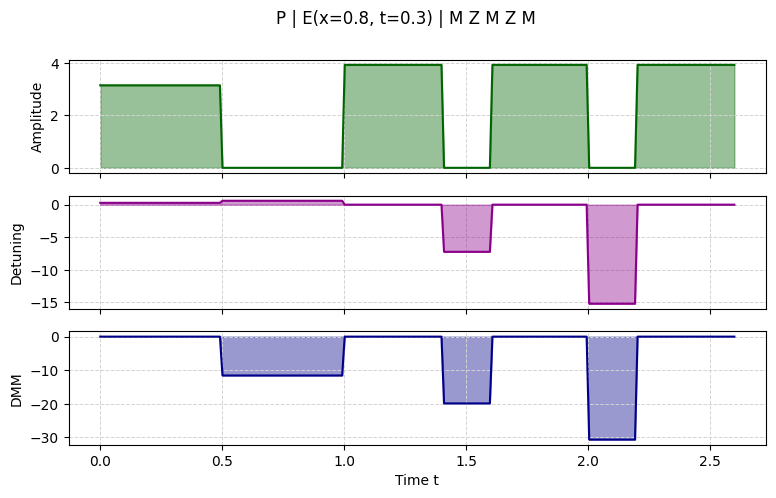

In [4]:
# Pulse schedule for one example point: Omega, global delta, DMM Delta (on atom 0).
# Horizontal axis = pulse time, not the PDE variable t.
theta_ex = np.random.default_rng(0).uniform(-np.pi, np.pi, 2 * K)
plt.figure(figsize=(9, 5))
make_program(0.8, 0.3, theta_ex).drive.draw()
plt.suptitle("P | E(x=0.8, t=0.3) | M Z M Z M")
plt.show()

### 1.4 Circuit output

$$f_\theta(x,t)=\langle00|\,U_\theta^\dagger Z_0U_\theta\,|00\rangle,\qquad U_\theta=M\,Z(\theta_2,\theta_3)\,M\,Z(\theta_0,\theta_1)\,M\;Z(x,t)\;P,$$

so

$$f_\theta(x,t)=\sum_{\omega_x,\omega_t\in\{-1,0,1\}}c_\omega(\theta)\,e^{\,i(\omega_xx+\omega_tt)} .$$

- `circuit_qoolqit` reads it from the emulator as $\langle Z_0\rangle=2\langle\hat{n}_0\rangle-1$.
- `circuit_numpy` propagates the state exactly through the same segments.
- `circuit` dispatches on `BACKEND` and counts circuit runs in `N_RUNS`.

In [5]:
def circuit_qoolqit(x, t, theta):
    program = make_program(x, t, theta)
    program.compile_to(device)
    n_occ = np.array(emulator.run(program).results().occupation[-1])
    return 2.0 * n_occ[0] - 1.0                         # <Z_0> = 2 <n_0> - 1


_U_FIXED = {}                                           # P and M segments never change: compute them once


def circuit_numpy(x, t, theta):
    psi = np.zeros(4, complex)
    psi[0] = 1.0
    for T, om, de, De in segments(x, t, theta):
        if om == 0.0:                                   # phase segment: H is diagonal, exp is exact and cheap
            psi = np.exp(-1j * T * np.diag(H_matrix(0.0, de, De))) * psi
        else:
            key = (T, om, de, De)
            if key not in _U_FIXED:
                _U_FIXED[key] = expm(-1j * T * H_matrix(om, de, De))
            psi = _U_FIXED[key] @ psi
    return float(np.real(psi.conj() @ Z0 @ psi))


N_RUNS = 0


def circuit(x, t, theta):
    # f_theta(x, t): one circuit run on the chosen backend
    global N_RUNS
    N_RUNS += 1
    return circuit_qoolqit(x, t, theta) if BACKEND == "qoolqit" else circuit_numpy(x, t, theta)

## 2. Plain and invariant QPINN

**Plain QPINN:** $f=f_\theta$.

**Invariant QPINN:**

$$f(x,t)=\tfrac12\big[f_\theta(x,t)+f_\theta(-x,-t)\big]=\sum_\omega\mathrm{Re}\,c_\omega(\theta)\,\cos(\omega_xx+\omega_tt),$$

which is invariant under $(x,t)\to(-x,-t)$. Each evaluation of $f$ costs two circuit runs.

In [6]:
def f_plain(x, t, theta):
    return circuit(x, t, theta)


def f_inv(x, t, theta):
    # invariant under (x, t) -> (-x, -t): average over the sign-flip group
    return 0.5 * (circuit(x, t, theta) + circuit(-x, -t, theta))

## 3. Derivatives

Both models are degree-1 trigonometric polynomials in $x$, in $t$ and in each $\theta_k$, all with gap 1. So, with $s=\pi/2$, the two-term rule is exact:

$$\partial_xf=\tfrac12\big[f(x+s,t)-f(x-s,t)\big],\qquad \partial_tf=\tfrac12\big[f(x,t+s)-f(x,t-s)\big],\qquad \partial_{\theta_k}f=\tfrac12\big[f(\theta+s\,e_k)-f(\theta-s\,e_k)\big].$$

`value_and_grad` applies the $\theta$ rule at one point. The check below compares all three rules with central finite differences.

In [7]:
def value_and_grad(f, x, t, theta):
    # f and df/dtheta at one point, two-term parameter-shift rule for every parameter
    val = f(x, t, theta)
    g = np.empty(len(theta))
    for k in range(len(theta)):
        e = np.zeros(len(theta))
        e[k] = SHIFT
        g[k] = (f(x, t, theta + e) - f(x, t, theta - e)) / 2
    return val, g


# Check the shift rules against central finite differences at one point (invariant model).
# h is not tiny on purpose: the QoolQit emulator has numerical noise of ~1e-5 to 1e-4 per run.
x0, t0, h = 0.7, 0.4, 0.05
e0 = np.eye(2 * K)[0]
checks = {
    "df/dx      ": ((f_inv(x0 + SHIFT, t0, theta_ex) - f_inv(x0 - SHIFT, t0, theta_ex)) / 2,
                    (f_inv(x0 + h, t0, theta_ex) - f_inv(x0 - h, t0, theta_ex)) / (2 * h)),
    "df/dt      ": ((f_inv(x0, t0 + SHIFT, theta_ex) - f_inv(x0, t0 - SHIFT, theta_ex)) / 2,
                    (f_inv(x0, t0 + h, theta_ex) - f_inv(x0, t0 - h, theta_ex)) / (2 * h)),
    "df/dtheta_0": ((f_inv(x0, t0, theta_ex + SHIFT * e0) - f_inv(x0, t0, theta_ex - SHIFT * e0)) / 2,
                    (f_inv(x0, t0, theta_ex + h * e0) - f_inv(x0, t0, theta_ex - h * e0)) / (2 * h)),
}
for name, (psr, fd) in checks.items():
    print(f"{name}  PSR {psr:+.5f}   finite diff {fd:+.5f}")

df/dx        PSR -0.60948   finite diff -0.60908
df/dt        PSR -0.12243   finite diff -0.12231
df/dtheta_0  PSR -0.08492   finite diff -0.08499


## 4. PDE, hard constraint and loss

### 4.1 PDE

$$u_t+u_x=-A\sin(x+t),\qquad x\in[-\pi,\pi)\ \text{(periodic)},\quad t\in[0,1],\qquad u(x,0)=A\cos x,\qquad A=0.5,$$

$$u^\ast(x,t)=A\cos x\cos t .$$

In [8]:
A = 0.5


def u0(x):
    return A * np.cos(x)


def du0(x):
    return -A * np.sin(x)


def source(x, t):
    return -A * np.sin(x + t)


def u_exact(x, t):
    return A * np.cos(x) * np.cos(t)

### 4.2 Hard constraint

$$u_\theta(x,t)=u_0(x)+m(t)\,f(x,t),\qquad m(t)=1-\cos t .$$

- Since $m(0)=0$, $u_\theta(x,0)=u_0(x)$ for every $\theta$, so the loss contains only the PDE residual.
- $m$ is even in $t$, so it does not break the symmetry of the invariant model.
- Periodicity in $x$ is automatic.

**Why the invariant model should do better.** The exact solution corresponds to $f^\ast=-A\cos x$.

- The invariant model contains only cosine terms. It has to match 4 cosine coefficients with 4 parameters.
- The plain model must also make its 4 sine coefficients vanish, which is 8 conditions for 4 parameters.

In [9]:
def m(t):                       # hard-constraint factor: m(0) = 0, even in t
    return 1.0 - np.cos(t)


def dm(t):
    return np.sin(t)


def u_model(f, x, t, theta):
    return u0(x) + m(t) * f(x, t, theta)

### 4.3 Residual and loss

**Residual.** With the hard constraint,

$$r=\partial_tu_\theta+\partial_xu_\theta-s=\sin t\,f+(1-\cos t)\,(f_t+f_x)+u_0'(x)-s(x,t).$$

**Collocation points.** $x\in\{-\pi,-\tfrac\pi2,0,\tfrac\pi2\}$ and $t\in\{0.25,0.5,0.75,1\}$, i.e. 16 points. The $x$ spacing equals the shift $\pi/2$, so `cached` runs each distinct point only once.

**Loss.**

$$\mathcal L=\frac1{|\mathcal C|}\sum_{\mathcal C}r^2=\|R\|^2 ,$$

where `residuals` returns the vector $R=r/\sqrt{|\mathcal C|}$.

In [10]:
x_col = np.linspace(-np.pi, np.pi, 4, endpoint=False)          # spacing pi/2 = SHIFT
t_col = np.array([0.25, 0.5, 0.75, 1.0])
colloc = [(x, t) for t in t_col for x in x_col]                 # 16 collocation points


def cached(fun, theta):
    # fun(x, t, theta) evaluated once per distinct point. x is 2pi-periodic, so x-shifts by pi/2
    # land on grid points and are not run twice.
    cache = {}

    def g(x, t):
        key = (round((x + np.pi) % TWO_PI - np.pi, 9), round(t, 9))
        if key not in cache:
            cache[key] = fun(*key, theta)
        return cache[key]
    return g


def residuals(theta, f, history):
    # R = PDE residuals / sqrt(|C|),  loss = R @ R.   r = sin t f + (1 - cos t)(f_t + f_x) + u0' - s
    F = cached(f, theta)
    r = [dm(t) * F(x, t)
         + m(t) * ((F(x, t + SHIFT) - F(x, t - SHIFT)) / 2 + (F(x + SHIFT, t) - F(x - SHIFT, t)) / 2)
         + du0(x) - source(x, t) for x, t in colloc]
    return np.array(r) / np.sqrt(len(colloc))

### 4.4 Jacobian

`jacobian` applies the $\theta$ rule on top of the $x$ and $t$ rules. The same runs also give $R$, so the loss of every LM iterate is recorded at no extra cost.

**Cost of one Jacobian.**

- The $x$-shifts land on grid points, which are cached. That leaves 48 points, each needing $1+2\cdot4=9$ evaluations of $f$.
- Plain QPINN: 432 circuit runs.
- Invariant QPINN: 864 circuit runs, since each $f$ needs two circuits.

In [11]:
def jacobian(theta, f, history):
    # dR/dtheta: shift rule in theta on top of the shift rule in x and t.
    # The same runs also give R, so the loss of every LM iterate is stored in `history` at no extra cost.
    G = cached(lambda x, t, th: value_and_grad(f, x, t, th), theta)
    r, rows = [], []
    for x, t in colloc:
        (v, g), (vtp, gtp), (vtm, gtm) = G(x, t), G(x, t + SHIFT), G(x, t - SHIFT)
        (vxp, gxp), (vxm, gxm) = G(x + SHIFT, t), G(x - SHIFT, t)
        r.append(dm(t) * v + m(t) * ((vtp - vtm) / 2 + (vxp - vxm) / 2) + du0(x) - source(x, t))
        rows.append(dm(t) * g + m(t) * ((gtp - gtm) / 2 + (gxp - gxm) / 2))
    r = np.array(r) / np.sqrt(len(colloc))
    history.append(float(r @ r))
    return np.array(rows) / np.sqrt(len(colloc))

## 5. Training

Each model is trained once with `least_squares(method="lm")`.

**Settings.**

- Same starting point $\theta_0$ for both models, drawn uniformly from $[-\pi,\pi)^4$.
- `xtol=1e-6`.
- `max_nfev=10`, which caps each run at fewer than 10 LM iterations. Rejected trial steps also use up evaluations, and `xtol` can stop a run earlier, so the two models may end with different iteration counts.

**Recording.** `history` stores the loss at every LM iterate, i.e. at every Jacobian evaluation.

In [12]:
MODELS = {"plain QPINN": f_plain, "invariant QPINN": f_inv}
theta0 = np.random.default_rng(0).uniform(-np.pi, np.pi, 2 * K)   # same starting point for both models
runs = []

for name, f in MODELS.items():
    history = []
    N_RUNS = 0
    tic = time.time()
    result = least_squares(residuals, theta0, jac=jacobian, method="lm", xtol=1e-6, max_nfev=10,
                           args=(f, history))
    if not np.isclose(history[-1], 2 * result.cost):
        history.append(2 * result.cost)           # final iterate, if LM stopped before evaluating its Jacobian
    runs.append(dict(model=name, theta=result.x.tolist(), loss=history,
                     circuit_runs=N_RUNS, seconds=time.time() - tic))
    print(f"{name:16s}: final loss {history[-1]:.2e}, {len(history) - 1} LM iterations, "
          f"{N_RUNS} circuit runs, {time.time() - tic:.0f}s")

plain QPINN     : final loss 4.98e-04, 7 LM iterations, 4032 circuit runs, 199s
invariant QPINN : final loss 1.81e-04, 7 LM iterations, 8064 circuit runs, 398s


## 6. Evaluation

Each trained model is compared with $u^\ast$ on a 25 × 6 grid over $x\in[-\pi,\pi]$, $t\in[0,1]$. The table lists final loss, max error, LM iterations and circuit runs. Both runs are saved to `results_invariant_qpinn/results_<BACKEND>.json`.

In [13]:
# Error against the exact solution on a grid (25 x 6 points per run)
xs = np.linspace(-np.pi, np.pi, 25)
ts = np.linspace(0.0, 1.0, 6)
for rec in runs:
    f, theta = MODELS[rec["model"]], np.array(rec["theta"])
    U = np.array([[u_model(f, x, t, theta) for x in xs] for t in ts])
    rec["max_error"] = float(np.abs(U - u_exact(xs[None, :], ts[:, None])).max())
    rec["U"] = U.tolist()

print(f"{'model':16s} {'final loss':>11s} {'max |u - u*|':>13s} {'iterations':>10s} {'circuit runs':>12s}")
for rec in runs:
    print(f"{rec['model']:16s} {rec['loss'][-1]:11.2e} {rec['max_error']:13.2e} "
          f"{len(rec['loss']) - 1:10d} {rec['circuit_runs']:12d}")

with open(os.path.join(RESULTS_DIR, f"results_{BACKEND}.json"), "w") as fh:
    json.dump(dict(backend=BACKEND, theta0=theta0.tolist(), runs=runs, xs=xs.tolist(), ts=ts.tolist()), fh, indent=1)

model             final loss  max |u - u*| iterations circuit runs
plain QPINN         4.98e-04      2.40e-02          7         4032
invariant QPINN     1.81e-04      1.43e-02          7         8064


## 7. Plots

- Loss vs LM iteration for both models, saved as `loss_<BACKEND>.png`.
- 3D surfaces of the analytical solution $u^\ast$, the invariant QPINN and the plain QPINN on the evaluation grid, with a shared color and $u$ scale, saved as `solution3d_<BACKEND>.png`.

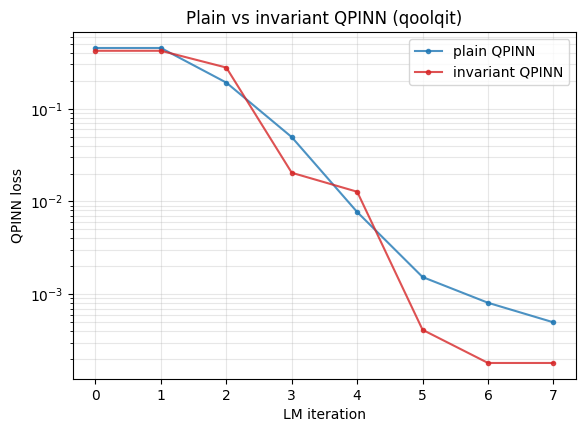

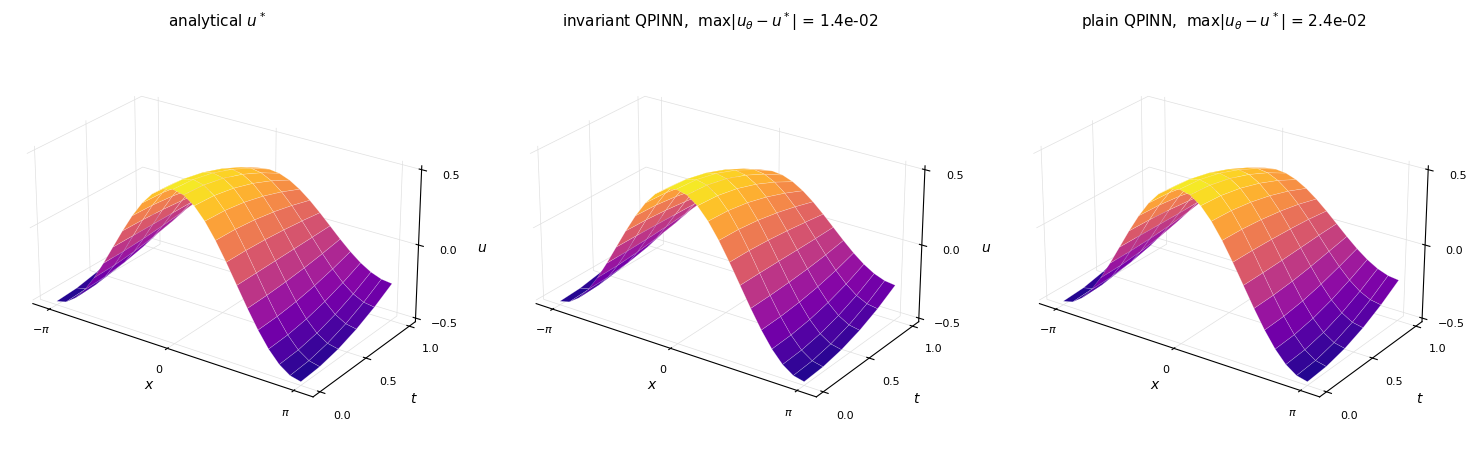

In [18]:
colors = {"plain QPINN": "C0", "invariant QPINN": "C3"}

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for rec in runs:
    ax.semilogy(rec["loss"], "o-", ms=3, color=colors[rec["model"]], alpha=0.8, label=rec["model"])
ax.set_xlabel("LM iteration")
ax.set_ylabel("QPINN loss")
ax.set_title(f"Plain vs invariant QPINN ({BACKEND})")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.savefig(os.path.join(RESULTS_DIR, f"loss_{BACKEND}.png"), dpi=150, bbox_inches="tight")
plt.show()

XS, TS = np.meshgrid(xs, ts)                                    # same 25 x 6 grid as the evaluation
surfaces = [(r"analytical $u^*$", u_exact(XS, TS))]
for name in ["invariant QPINN", "plain QPINN"]:
    rec = next(r for r in runs if r["model"] == name)
    surfaces.append((name + rf",  $\max|u_\theta-u^*|$ = {rec['max_error']:.1e}", np.array(rec["U"])))
lim = 1.05 * max(np.abs(U).max() for _, U in surfaces)          # shared color and z scale

with plt.rc_context({"grid.color": "0.88", "grid.linewidth": 0.5, "axes.labelsize": 10}):
    fig = plt.figure(figsize=(15, 4.6))
    for k, (title, U) in enumerate(surfaces):
        a = fig.add_subplot(1, 3, k + 1, projection="3d")
        a.plot_surface(XS, TS, U, cmap="plasma", vmin=-lim, vmax=lim,
                       edgecolor=(1.0, 1.0, 1.0, 0.4), linewidth=0.3, antialiased=True)
        a.view_init(elev=25, azim=-55)
        a.set_box_aspect((1.8, 1.0, 0.9))                        # x is the long direction
        for axis in (a.xaxis, a.yaxis, a.zaxis):
            axis.set_pane_color((1.0, 1.0, 1.0, 0.0))            # transparent background panes
        a.set_xticks([-np.pi, 0, np.pi])
        a.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
        a.set_yticks([0, 0.5, 1])
        a.set_zticks([-A, 0, A])
        a.set_zlim(-lim, lim)
        for axis_name in "xyz":
            a.tick_params(axis=axis_name, labelsize=8)
        a.set_xlabel("$x$")
        a.set_ylabel("$t$")
        a.set_zlabel("$u$")
        a.set_title(title, fontsize=11)
    fig.subplots_adjust(left=0.0, right=1.0, bottom=0.02, top=0.92, wspace=0.02)
    fig.savefig(os.path.join(RESULTS_DIR, f"solution3d_{BACKEND}.png"), dpi=150, bbox_inches="tight")
    plt.show()